# Libraries

In [129]:
import pandas as pd
import numpy as np
import os
import matplotlib.font_manager as fm
import time
import warnings

# Plotting Libs
import matplotlib.pyplot as plt 
from sklearn.tree import plot_tree
from xgboost import plot_importance
import shap

# Scaler Libs
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# CV Libs
from sklearn.model_selection import GridSearchCV 
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from sklearn.experimental import enable_halving_search_cv  # must be imported first
from sklearn.model_selection import HalvingGridSearchCV
import statsmodels.api as sm

# Model Libs
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Accuracy Libs
from sklearn.metrics import accuracy_score , classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score

# Resampling Libs
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler


# Load Data

In [130]:
start_time = time.time()

In [131]:
df1 = pd.read_pickle(r".\df_dummies\df1_dummies.pkl")
df2 = pd.read_pickle(r".\df_dummies\df2_dummies.pkl")
df3 = pd.read_pickle(r".\df_dummies\df3_dummies.pkl")
df4 = pd.read_pickle(r".\df_dummies\df4_dummies.pkl")

# Accuracy tests/ Roc Function


In [132]:
def accuracy(dfi, i, model, X_test, y_test, y_pred, title):
    print(f"Model : Phase {i} - {title}")

    print("\na).\nClassification Report :")
    class_rep = classification_report(y_test, y_pred)
    print(class_rep)
    print("\nb).\nF1 Score :")
    f1 = f"{f1_score(y_test, y_pred, average='weighted'):.2f}"
    print(f1)

    print("\nc).\nBalanced Accuracy Score :")
    acc_bal = f"{balanced_accuracy_score(y_test, y_pred) * 100:.2f}%"
    print(acc_bal)

    print("\nd).\nMatthews Correlation Coefficient (MCC) :")
    mcc = f"{matthews_corrcoef(y_test, y_pred):.2f}"
    print(mcc)

    print("\nd).\nPlots :")
    fig , ax = plt.subplots(figsize = (20, 6), nrows = 1, ncols = 3)

    ConfusionMatrixDisplay.from_predictions(y_test , y_pred, ax = ax[0]);
    RocCurveDisplay.from_estimator(model, X_test, y_test, pos_label = 1, ax = ax[1], name = f'{title}');  # Completed = 0, Terminated = 1
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, pos_label=1, ax=ax[2], name=f'{title}')
    
    print(f"ROC AUC : {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]).round(3)}") # Predict Probabilities for accurate ROC Auc")
    print(f"PR AUC : {average_precision_score(y_test, model.predict_proba(X_test)[:, 1]).round(3)}")

    plt.suptitle(f"Phase {i} - {title}", fontsize = 11, fontweight = 'bold')

    # Confusion Matrix
    ax[0].set_title("1. Confusion Matrix", fontsize = 10, fontweight = 'bold')
    ax[0].set_xlabel("Predicted Label", fontsize = 10, fontweight = 'bold')
    ax[0].set_ylabel("True Label", fontsize = 10, fontweight = 'bold')
    
    # Roc Curve
    ax[1].set_title("2. ROC Curve" , fontsize = 10, fontweight = 'bold')
    ax[1].set_ylabel("Sensitivity - Recall (TPR)", fontsize = 10, fontweight = 'bold')
    ax[1].set_xlabel("1 - Specificity (FPR) ", fontsize = 10, fontweight = 'bold')

    # PR Cruve
    ax[2].set_title("3. PR Curve", fontsize = 10, fontweight = 'bold')
    ax[2].set_ylabel("Precision (PPV)", fontsize = 10, fontweight = 'bold')
    ax[2].set_xlabel("Sensitivity - Recall (TPR)", fontsize = 10, fontweight = 'bold')

    plt.show()      
    plt.close(fig)  

    return acc_bal, class_rep, mcc, f1

# SHAP Function
- SHAP Summary PLot:
- Impact on the prediction (how much a feature contributes to pushing the prediction left (negative) or right (positive)).
- Blue = low feature value.
- Red = high feature value.

- Example: Enrollment_Log:
- High values (red) → strong negative SHAP values → push prediction to Completed.
- Low values (blue) → positive SHAP values → push toward Terminated.
- SHAP X-axis shows how much each feature pushes the prediction toward class 0 or 1, in log-odds space. (value -5)

In [133]:
# SHAP dataset overview
def fun_shap(i, model, X_test, model_str):
    X_test_sam = shap.sample(X_test, 100)
    explainer = shap.Explainer(model.predict, X_test_sam)
    shap_values = explainer(X_test_sam)

    # Files/Paths 
    model_str = model_str
    folder_shap = "shap_plots"
    os.makedirs(folder_shap, exist_ok=True)
    filename = f"df{i}_{model_str}_shap_plot.png"
    filepath = os.path.join(folder_shap, filename)

#### Summary Plot SHAP --> Global overview 
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        shap.summary_plot(shap_values, X_test_sam, plot_size=(8, 4), max_display = 15, show=False)
    plt.title(f"df{i} - {model_str} - SHAP Summary Plot", fontsize = 12, fontweight="bold", pad = 15)
    plt.xlabel("SHAP value (impact on model output)", fontsize=12, labelpad=15) 

    ax = plt.gca()
    for label in ax.get_yticklabels()[-7:]:
        label.set_fontweight("bold")
    # Save Summary Plot
    fig = plt.gcf()
    fig.savefig(filepath, dpi = 100, bbox_inches = 'tight')
    plt.show()
    plt.close(fig)

#### Waterfall Plot --> 1 data point prediction --> Local overview
    '''plt.figure(figsize = (20, 3), dpi = 100)
    shap.waterfall_plot(shap_values[0], max_display = 10, show = False) 
    plt.title(f"{model_str} SHAP Waterfall Plot", fontsize = 12, fontweight = "bold", pad = 15)
    plt.tight_layout()
    plt.show()'''

#### SHAP mean values - top features
    shap_value_mean = np.abs(shap_values.values).mean(axis=0).round(3)
    shap_important = pd.DataFrame({
        "Feature": X_test_sam.columns,
        f"df{i}_{model_str}_Shap_Mean" : shap_value_mean
    })
    shap_important = shap_important.sort_values(by = f"df{i}_{model_str}_Shap_Mean", ascending=False).head(8).reset_index(drop=True)
    # Save Mean Shap values
    shap_important.to_pickle(f"./shap_plots/df{i}_{model_str}_mean_shap.pkl")
    display(shap_important)
    
    return shap_important


# Data Preparation

## Df Input

In [134]:
display(df1.shape)
display(df2.shape)
display(df3.shape)
display(df4.shape)

(21829, 73)

(21228, 73)

(13966, 73)

(13246, 73)

In [135]:
i = 4
dfi = df4

## X , y

In [136]:
X = dfi.drop(columns = ["Study_Status_Bin"], axis = 1)
y = dfi["Study_Status_Bin"]

# initial X features
X.shape # Check that initial shape of dfi was not changed.

(13246, 72)

## Train - Test Split

In [137]:
# Train-Test Split
X_train_tts, X_test_tts, y_train_tts, y_test_tts = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

# Imbalanced 0 row = Compeleted, row 1 = terminated
display(f'Terminated/Completed: {y_train_tts.value_counts().iloc[1]/y_train_tts.value_counts().iloc[0]}') 
display(X_train_tts.shape[0], X_test_tts.shape[0])

# EPV
display(y_train_tts[y_train_tts == 1].sum()/(X_train_tts.shape[1]+1))

'Terminated/Completed: 0.21110984112469997'

10596

2650

25.301369863013697

## Resample
- Datasets are imbalanced towards with the negative class the majority. (i.e. COMPLETED = 0) 
- May induce bias towards majority class. 
- Resample train set only, so model will be correctly trained..
    --> Avoids information leaking to test set. test set always similar to true cases.
- Performance evaluated on unsampled test set, with real data distribution.

In [138]:
res = RandomUnderSampler(sampling_strategy = 'auto', random_state = 42)
X_train_res, y_train_res = res.fit_resample(X_train_tts, y_train_tts) 

# Final train/test ratio
display(f'X_test/X_train : {X_test_tts.shape[0]}/{X_train_res.shape[0]} = {(X_test_tts.shape[0]/X_train_res.shape[0])}')
display(f'X_train_features/X_train_sample : {X_train_res.shape[1]}/{X_train_res.shape[0]} = {(X_train_res.shape[1]/X_train_res.shape[0])}')

'X_test/X_train : 2650/3694 = 0.7173795343800758'

'X_train_features/X_train_sample : 72/3694 = 0.01949106659447753'

## Scaling
- Scale after resample, similarly to train_test_Split so it wont take the skewed distribution of imbalanced data.
- Scaling always after dataset split

In [139]:
def fun_scale(X_train_res, X_test_tts):
    X_train_sc = X_train_res.copy()
    X_test_sc = X_test_tts.copy()

    cont_cols = [col for col in X_train_sc.columns 
                    if (('counts' in col.lower() or 'log' in col.lower()) and
                        not any(x in col.lower() for x in ['bin', 'categ', 'list']))]
    
    # scaler = StandardScaler(with_mean = True, with_std = True)
    scaler = MinMaxScaler()

    X_train_sc[cont_cols] = pd.DataFrame(scaler.fit_transform(X_train_sc[cont_cols]),
        columns = cont_cols, index=X_train_sc.index)

    X_test_sc[cont_cols] = pd.DataFrame(scaler.transform(X_test_sc[cont_cols]),
        columns = cont_cols, index=X_test_sc.index)
    
    return X_train_sc, X_test_sc

X_train_sc, X_test_sc = fun_scale(X_train_res, X_test_tts)

# check if any continues features appear negative values (Negative values are not minigfull to dataset)
col = [col for col in X_train_sc.columns 
                    if (('_Counts' in col or '_Log' in col) and
                        not any(x in col for x in ['_Bin', '_Categ', '_List']))]
X_train_sc[col].describe().round(2)

,Funder_Counts_Log,Adverse_Counts_Log,Arm_Counts_Log,City_Counts_Log,Enrollment_Counts_Log,"Enrollment_Log_x_Bacterial, Mycoses, Virus",Enrollment_Log_x_Cardiovascular,"Enrollment_Log_x_Digestive System, Nutritional, Metabolic",Enrollment_Log_x_Endocrine System,Enrollment_Log_x_Eye,...,Enrollment_Log_x_Neoplasms,Enrollment_Log_x_Nervous System,"Enrollment_Log_x_Pathological Conditions, Signs, Symptoms","Enrollment_Log_x_Phenomena, Processes","Enrollment_Log_x_Psychiatry, Psychology, Anthropology, Sociology","Enrollment_Log_x_Respiratory, Circulatory","Enrollment_Log_x_Skin, Tissue, Wounds","Enrollment_Log_x_Stomatognathic, Otorhinolaryngologic","Enrollment_Log_x_Urogenital, Pregnancy",Enrollment_Log_x_City_Log
count,3694.00,3694.00,3694.00,3694.00,3694.00,3694.00,3694.00,3694.00,3694.00,3694.00,...,3694.00,3694.00,3694.00,3694.00,3694.00,3694.00,3694.00,3694.00,3694.00,3694.00
mean,0.07,0.07,0.18,0.14,0.27,0.04,0.04,0.06,0.02,0.01,...,0.02,0.07,0.09,0.02,0.07,0.03,0.03,0.01,0.04,0.06
std,0.12,0.16,0.12,0.12,0.17,0.13,0.12,0.15,0.11,0.09,...,0.09,0.18,0.17,0.11,0.16,0.11,0.12,0.09,0.13,0.08
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.19,0.11,0.15,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02
50%,0.00,0.00,0.19,0.11,0.29,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.04
75%,0.17,0.00,0.19,0.11,0.38,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.06
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


## X_train_X_test

In [ ]:
X_train = X_train_sc.copy() # 
X_test = X_test_sc.copy()
y_train = y_train_res.copy() #
y_test = y_test_tts.copy()

## Rename

In [141]:
def fun_rename(X_train, X_test, y_train, y_test):

    X_train.columns = X_train.columns.str.replace(r'List_|Detail_|Adv_Syst_|Adv_', "", regex=True)
    X_train.columns = X_train.columns.str.replace(r'_(Counts_Log|Counts|Log)', " Count", regex=True)
    X_train.columns = X_train.columns.str.replace(r'Funder_Type', "Funder", regex=True)
    X_train.columns = X_train.columns.str.replace(r'_(Bin|Type)', "", regex=True)
    X_train.columns = X_train.columns.str.replace(r'_', " ", regex=True)
    X_train.columns = X_train.columns.str.replace(r", ", " ", regex=True)

    X_test.columns = X_test.columns.str.replace(r'List_|Detail_|Adv_Syst_|Adv_', "", regex=True)
    X_test.columns = X_test.columns.str.replace(r'_(Counts_Log|Counts|Log)', " Count", regex=True)
    X_test.columns = X_test.columns.str.replace(r'Funder_Type', "Funder", regex=True)
    X_test.columns = X_test.columns.str.replace(r'_(Bin|Type)', "", regex=True)
    X_test.columns = X_test.columns.str.replace(r'_', " ", regex=True)
    X_test.columns = X_test.columns.str.replace(r", ", " ", regex=True)


    y_train.name = y_train.name.replace('Study_Status_Bin', 'Study Status')
    y_test.name = y_test.name.replace('Study_Status_Bin', 'Study Status')

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = fun_rename(X_train, X_test, y_train, y_test)

X_train.columns.to_list()

['Funder Industry',
 'Funder Count',
 'Placebo',
 'Standard Care',
 'Healthy',
 'Adverse Count',
 'Allocation',
 'Arm Count',
 'Global',
 'City Count',
 'Enrollment Count',
 'Sex MALE',
 'Age ADULT',
 'Age OLDER ADULT',
 'Intervention BIOLOGICAL',
 'Intervention DEVICE',
 'Intervention DRUG',
 'Intervention INTERV UNSPES',
 'Intervention PROCEDURE',
 'Intervention Route Injection',
 'Intervention Route Oral',
 'Intervention Route Surgical',
 'Intervention Route Topical',
 'Conditions Bacterial Mycoses Virus',
 'Conditions Cardiovascular',
 'Conditions Digestive System Nutritional Metabolic',
 'Conditions Endocrine System',
 'Conditions Eye',
 'Conditions Hemic Lymphatic Immune System',
 'Conditions Hereditary Neonatal Abnormalities',
 'Conditions Musculoskeletal Neural',
 'Conditions Neoplasms',
 'Conditions Nervous System',
 'Conditions Pathological Conditions Signs Symptoms',
 'Conditions Phenomena Processes',
 'Conditions Psychiatry Psychology Anthropology Sociology',
 'Conditions R

## Drop Cols

In [142]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data["Feature"] != "const"]

display(vif_data[vif_data["VIF"] > 5].sort_values(by = 'VIF', ascending = False))

,Feature,VIF
72,Enrollment Count x City Count,9.985142
10,City Count,7.178097
33,Conditions Nervous System,6.887018
64,Enrollment Count x Nervous System,6.857681
62,Enrollment Count x Musculoskeletal Neural,6.573793
67,Enrollment Count x Psychiatry Psychology Anthr...,6.378507
36,Conditions Psychiatry Psychology Anthropology ...,6.292507
31,Conditions Musculoskeletal Neural,6.268843
6,Adverse Count,5.870026
65,Enrollment Count x Pathological Conditions Sig...,5.640440


In [143]:
# X_train = X_train.drop(columns = ['City Count'], axis = 1)
# X_train = X_train.drop(columns = [col for col in X_test.columns if 'Enrollment Count x' in col], axis = 1)

# X_test = X_test.drop(columns = ['City Count'], axis = 1)
# X_test = X_test.drop(columns = [col for col in X_test.columns if 'Enrollment Count x' in col], axis = 1)


# Models

## A) Classic Classification

### Logistic (L1)

Model : Phase 4 - Lasso Logistic Regression (L1)

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      2188
           1       0.53      0.79      0.63       462

    accuracy                           0.84      2650
   macro avg       0.74      0.82      0.77      2650
weighted avg       0.88      0.84      0.85      2650


b).
F1 Score :
0.85

c).
Balanced Accuracy Score :
81.95%

d).
Matthews Correlation Coefficient (MCC) :
0.55

d).
Plots :
ROC AUC : 0.893
PR AUC : 0.795


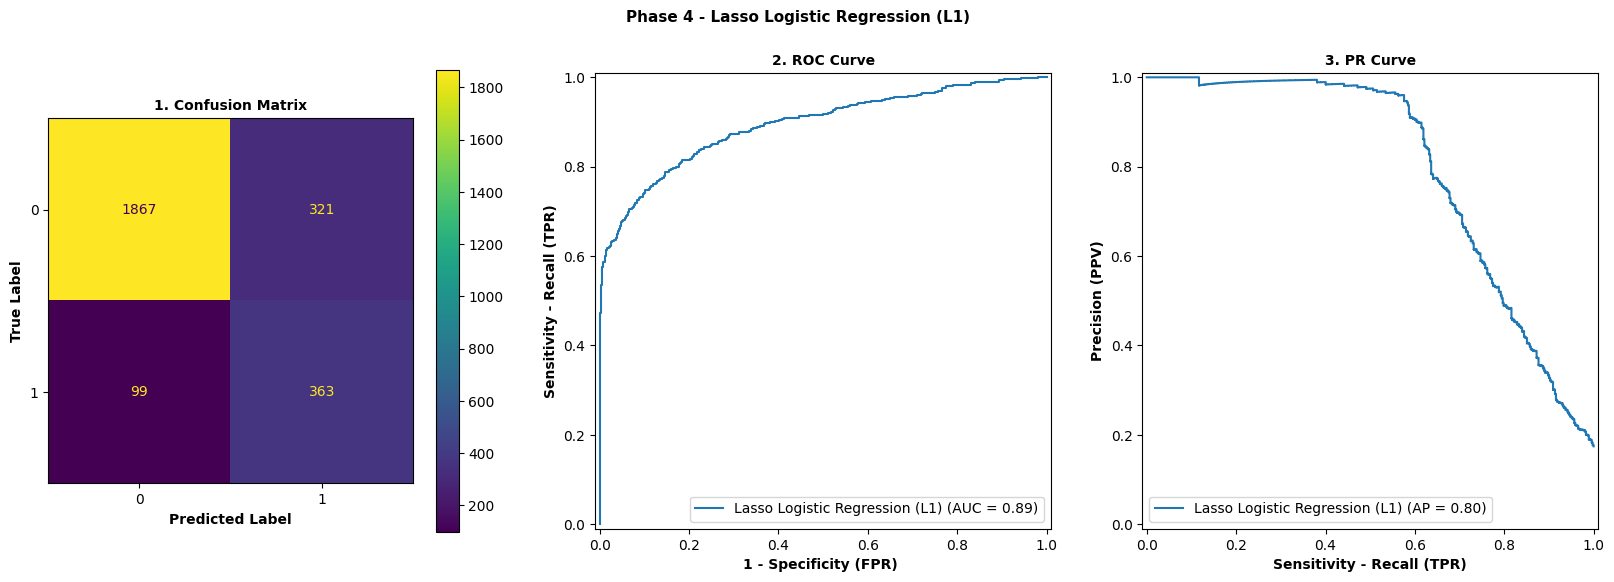

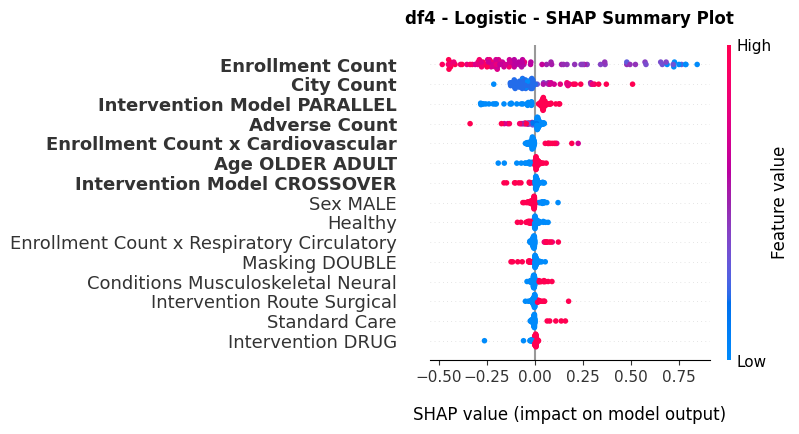

,Feature,df4_Logistic_Shap_Mean
0,Enrollment Count,0.301
1,City Count,0.091
2,Intervention Model PARALLEL,0.070
3,Adverse Count,0.032
4,Enrollment Count x Cardiovascular,0.025
5,Age OLDER ADULT,0.020
6,Intervention Model CROSSOVER,0.018
7,Sex MALE,0.016


In [144]:
# Model
log_reg = LogisticRegression(penalty = 'l1', max_iter = 5000 , solver = 'saga', class_weight = 'balanced',  random_state = 42)  

# Final Model
log_model = log_reg.fit(X_train, y_train)

# y_pred
y_pred_log_l1 = log_model.predict(X_test)

# Accuracy Score
ba_log, class_log, mcc_log, f1_log = accuracy(dfi, i, log_model, X_test, y_test, y_pred_log_l1, "Lasso Logistic Regression (L1)")

log_shap = fun_shap(i, log_model, X_test, 'Logistic')


### LDA - Linear Discriminant Analysis

- QDA and LDA assume Gaussian distributions.

Best Parameters : {'n_components': 1, 'shrinkage': None}
Best Estimator : LinearDiscriminantAnalysis(n_components=1, solver='lsqr', store_covariance=True)
Model : Phase 4 - Linear Discriminant Analysis (LDA)

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      2188
           1       0.56      0.75      0.64       462

    accuracy                           0.85      2650
   macro avg       0.75      0.81      0.78      2650
weighted avg       0.88      0.85      0.86      2650


b).
F1 Score :
0.86

c).
Balanced Accuracy Score :
81.21%

d).
Matthews Correlation Coefficient (MCC) :
0.56

d).
Plots :
ROC AUC : 0.891
PR AUC : 0.793


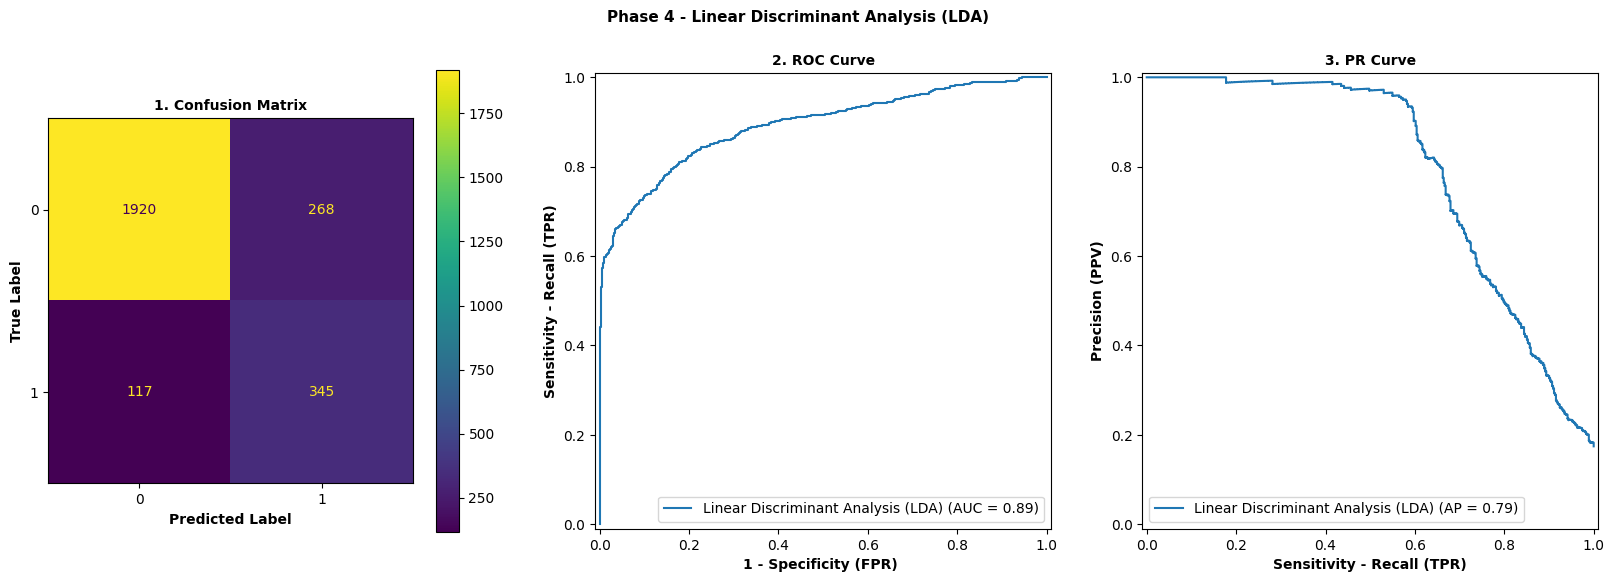

In [145]:
# Model
lda = LDA(store_covariance = True, solver = 'lsqr') # Use solver = lsqr if cv needed.

# HPO
param_grid = {
    "shrinkage" : [None, "auto"] + list(np.linspace(0.01, 1.0, 10)), # sklearn doc: float between 0 and 1
    'n_components' : np.arange(1, min(X_train.shape[1], len(np.unique(y_train)) - 1) + 1)
    } 
# CV
grid = GridSearchCV(estimator = lda, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1) 

# Final Model
lda_model = grid.fit(X_train, y_train) # automatically gives the best.estimator
print(f'Best Parameters : {lda_model.best_params_}')
print(f'Best Estimator : {lda_model.best_estimator_}')

# y_pred
y_pred_lda = lda_model.predict(X_test)

# Accuracy Score
ba_lda, class_lda, mcc_lda, f1_lda = accuracy(dfi, i, lda_model, X_test, y_test, y_pred_lda, "Linear Discriminant Analysis (LDA)")

# SHAP
# lda_shap = fun_shap(i, lda_model, X_test, 'LDA')

### QDA - Quantratic Discriminant Analysis
- QDA very sensistive to collinear data!
QDA and LDA assume Gaussian distributions.

"Best Parameters : {'reg_param': 0.0}"

'Best Estimator : QuadraticDiscriminantAnalysis(store_covariance=True)'

Model : Phase 4 - Quantric Discriminant Analysis (QDA)

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      2188
           1       0.59      0.68      0.63       462

    accuracy                           0.86      2650
   macro avg       0.76      0.79      0.77      2650
weighted avg       0.87      0.86      0.87      2650


b).
F1 Score :
0.87

c).
Balanced Accuracy Score :
79.11%

d).
Matthews Correlation Coefficient (MCC) :
0.55

d).
Plots :
ROC AUC : 0.861
PR AUC : 0.688


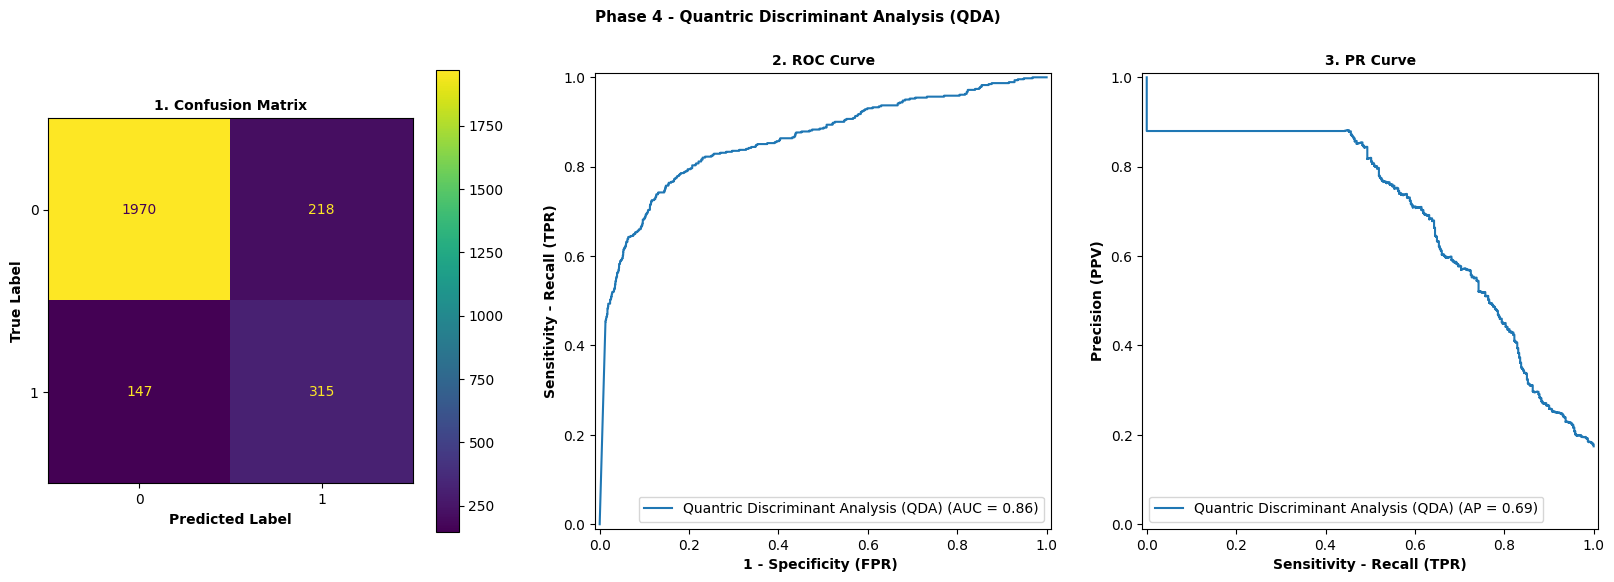

In [146]:
# Model
# QDA does not assume linear relation X - y --> lasso assumes. 
qda = QDA(store_covariance = True)

# HPO
param_grid = {
    "reg_param": np.linspace(0, 1, 30) # value range [0,1]
    }

# CV
grid = GridSearchCV(estimator = qda, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1) # cv = 5 default # n_jobs = -1 avoid overload

# Final model
qda_model = grid.fit(X_train, y_train)
display(f'Best Parameters : {qda_model.best_params_}')
display(f'Best Estimator : {qda_model.best_estimator_}')

# y_pred
y_pred_qda = qda_model.predict(X_test)

# Accuracy Score
ba_qda, class_qda, mcc_qda, f1_qda = accuracy(dfi, i, qda_model, X_test, y_test, y_pred_qda, "Quantric Discriminant Analysis (QDA)")

# SHAP
# qda_shap = fun_shap(i, qda_model, X_test, 'QDA')


### Elastic Net Logistic Regression
- l1_ratio l1 / l2 = Elastic Net
- l1_ratio = 1 = Lasso (l1)
- l1_ratio = 0 = Ridge (l2) 
- 0 < l1_ratio < 1 

"Best Parameters : {'C': 1, 'l1_ratio': 1.0}"

"Best Estimator : LogisticRegression(C=1, l1_ratio=1.0, max_iter=3000, penalty='elasticnet',\n                   random_state=42, solver='saga')"

Model : Phase 4 - Elastic Net Logistic Regression

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      2188
           1       0.53      0.79      0.63       462

    accuracy                           0.84      2650
   macro avg       0.74      0.82      0.77      2650
weighted avg       0.88      0.84      0.85      2650


b).
F1 Score :
0.85

c).
Balanced Accuracy Score :
81.95%

d).
Matthews Correlation Coefficient (MCC) :
0.55

d).
Plots :
ROC AUC : 0.893
PR AUC : 0.795


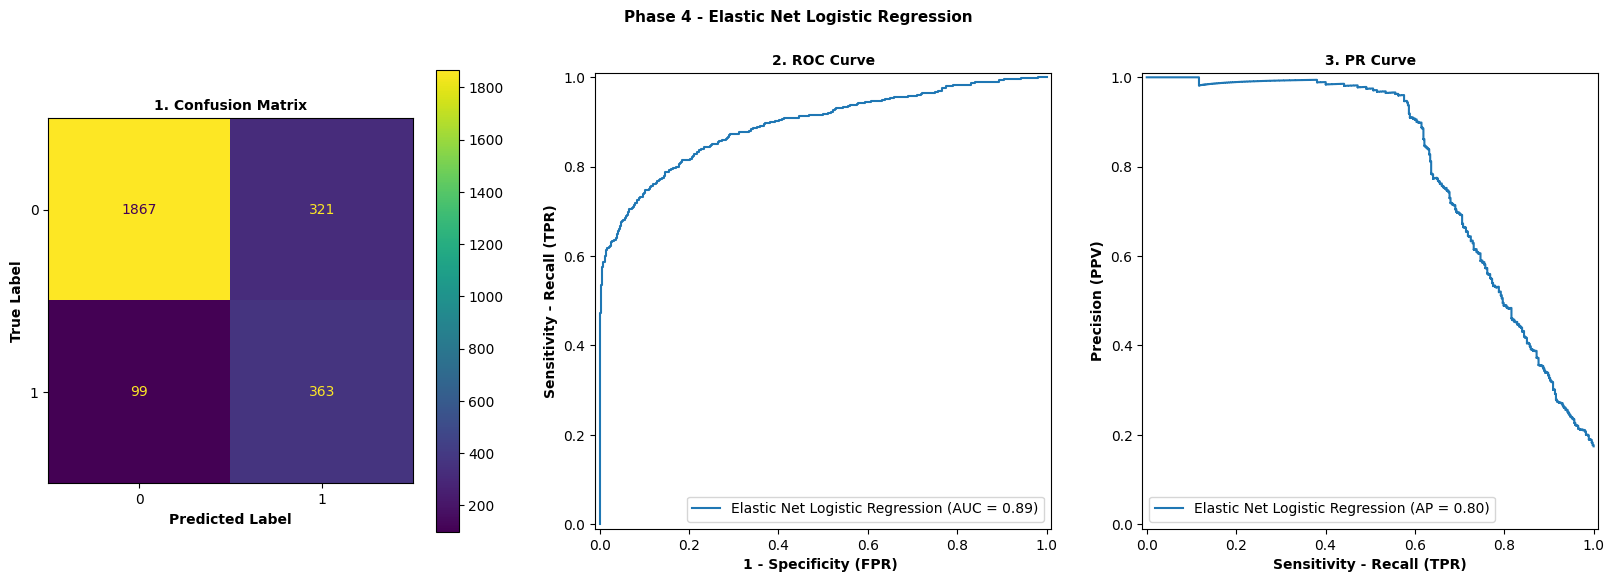

In [147]:

# Model (4+min df5)
log_el = LogisticRegression(penalty = 'elasticnet', max_iter = 3000, solver = "saga", random_state = 42)   

# HPO
param_grid = {
    'C': [0.01, 1, 10, 100, 1000],
    "l1_ratio" : np.linspace(0.01, 1, 10, endpoint = True)
    } 
# CV
grid = GridSearchCV(estimator = log_el, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
el_model = grid.fit(X_train, y_train)  
display(f'Best Parameters : {el_model.best_params_}')
display(f'Best Estimator : {el_model.best_estimator_}')

# y_pred
y_pred_el = el_model.predict(X_test)

# Accuracy Score
ba_el, class_el, mcc_el, f1_el = accuracy(dfi, i, el_model, X_test, y_test, y_pred_el, "Elastic Net Logistic Regression")

# SHAP
# el_shap = fun_shap(i, el_model, X_test, 'Elastic_Net')


## B) ML Classification

### KNN - K Nearest Neighbors

"Best Parameters : {'n_neighbors': 100}"

'Best Estimator : KNeighborsClassifier(n_neighbors=100)'

Model : Phase 4 - K-Nearest Neighbors Classifier (KNN)

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      2188
           1       0.31      0.69      0.43       462

    accuracy                           0.68      2650
   macro avg       0.61      0.68      0.60      2650
weighted avg       0.81      0.68      0.71      2650


b).
F1 Score :
0.71

c).
Balanced Accuracy Score :
68.32%

d).
Matthews Correlation Coefficient (MCC) :
0.28

d).
Plots :
ROC AUC : 0.759
PR AUC : 0.481


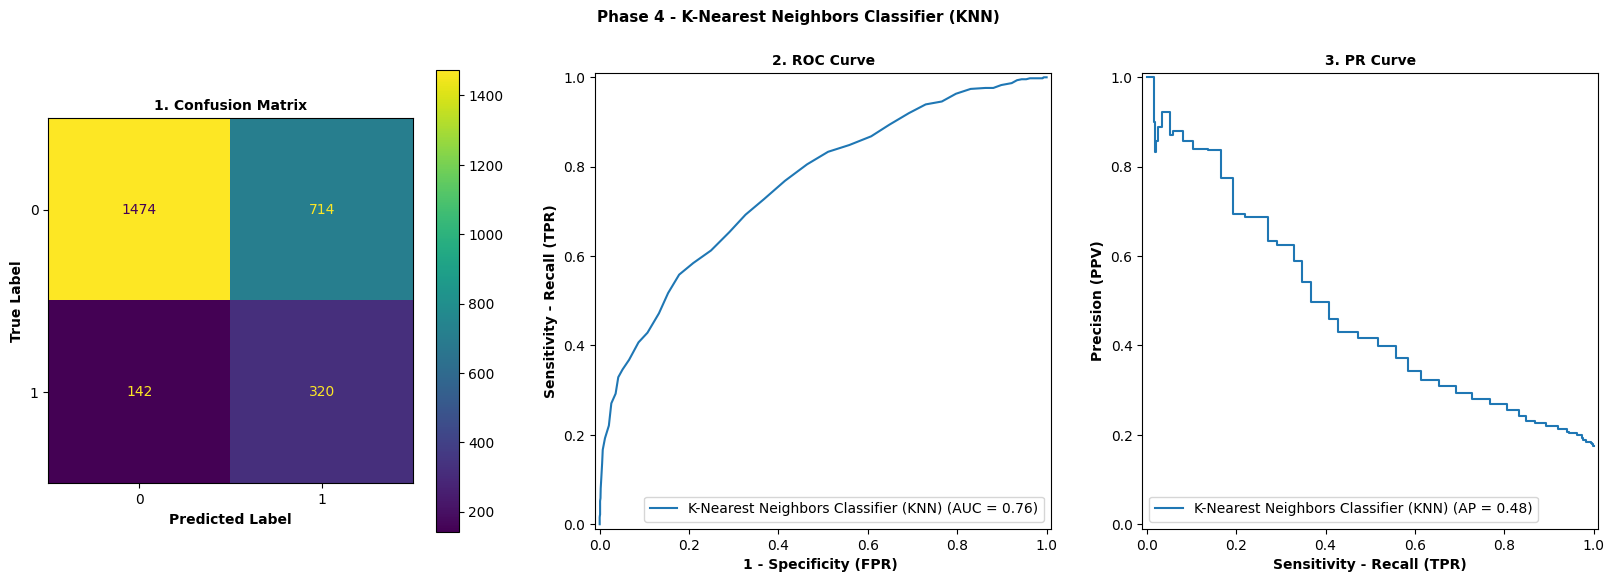

In [148]:
# Model 
knn = KNeighborsClassifier()

# HPO 
param_grid = {
    "n_neighbors" : np.linspace(5, 100, 30, endpoint = True).astype(int)
    } 

# CV
grid = GridSearchCV(estimator = knn , param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
knn_model = grid.fit(X_train, y_train)
display(f'Best Parameters : {knn_model.best_params_}')
display(f'Best Estimator : {knn_model.best_estimator_}')

# y_pred
y_pred_knn = knn_model.predict(X_test)

# Accuracy Score
ba_knn, class_knn, mcc_knn, f1_knn = accuracy(dfi, i, knn_model, X_test, y_test, y_pred_knn, "K-Nearest Neighbors Classifier (KNN)")

# SHAP
# knn_shap = fun_shap(i, knn_model, X_test, 'KNN')

### SVC - Support Vector Classifier
- Always Chooses rbf
- poly is not going to be checked as it extremely increases compuational time, wihtout never be chosen. 
- rbf can find some non-linear boundries close to poly if needed. 


"Best Parameter: {'C': 7.742636826811269, 'gamma': 'auto'}"

"Best Estimator: SVC(C=7.742636826811269, class_weight='balanced', gamma='auto',\n    probability=True, random_state=42)"

Model : Phase 4 - Support Vector Classifier (SVC)

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      2188
           1       0.63      0.72      0.67       462

    accuracy                           0.88      2650
   macro avg       0.78      0.81      0.80      2650
weighted avg       0.88      0.88      0.88      2650


b).
F1 Score :
0.88

c).
Balanced Accuracy Score :
81.49%

d).
Matthews Correlation Coefficient (MCC) :
0.60

d).
Plots :
ROC AUC : 0.892
PR AUC : 0.786


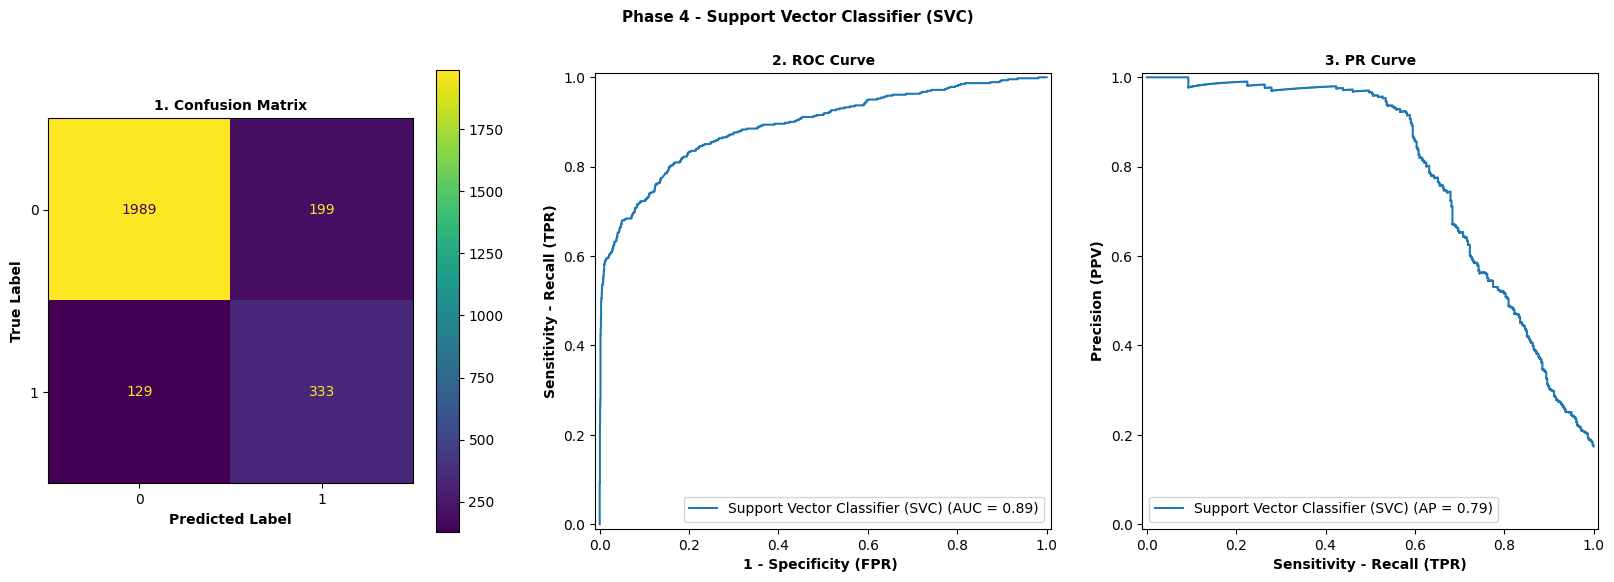

In [149]:
# Model
svc = SVC(probability = True, random_state = 42, class_weight = 'balanced', kernel = 'rbf')
 
# HPO
param_grid = {
    "C": np.logspace(0, 4, 10),
    "gamma": ["scale", "auto"]
}
# CV
grid = GridSearchCV(estimator = svc, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1,)

# Final Model
svc_model = grid.fit(X_train, y_train)
display(f'Best Parameter: {svc_model.best_params_}')
display(f'Best Estimator: {svc_model.best_estimator_}')

# y_pred
y_pred_svc = svc_model.predict(X_test)

# Accuracy Score
ba_svc, class_svc, mcc_svc, f1_svc = accuracy(dfi, i, svc_model, X_test, y_test, y_pred_svc, "Support Vector Classifier (SVC)")

# SHAP
# svc_shap = fun_shap(i, svc_model, X_test, 'SVC') # Hide for computational efficacy

### Tree (Pruned)


In [150]:
# cc_alphas values meaningful for dataset
tree = DecisionTreeClassifier(random_state = 42)
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
display(ccp_alphas.min(), ccp_alphas.mean(), ccp_alphas.max())

0.0

0.0013332980060650687

0.19190718649049032

"Best Parameter criterion/max_depth: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}"

"Best Estimator : DecisionTreeClassifier(class_weight='balanced', criterion='entropy',\n                       max_depth=4, random_state=42)"

Model : Phase 4 - Decision Tree Classifier

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2188
           1       0.76      0.68      0.71       462

    accuracy                           0.91      2650
   macro avg       0.84      0.81      0.83      2650
weighted avg       0.90      0.91      0.90      2650


b).
F1 Score :
0.90

c).
Balanced Accuracy Score :
81.46%

d).
Matthews Correlation Coefficient (MCC) :
0.66

d).
Plots :
ROC AUC : 0.882
PR AUC : 0.737


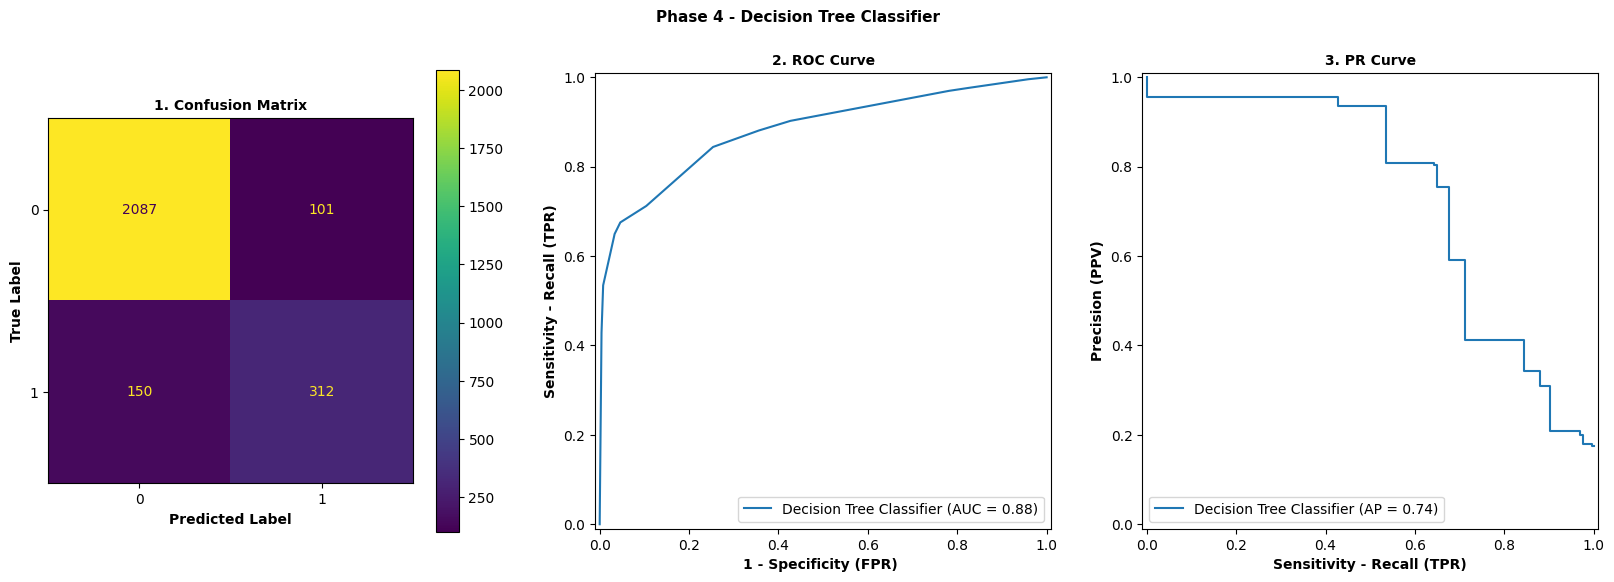

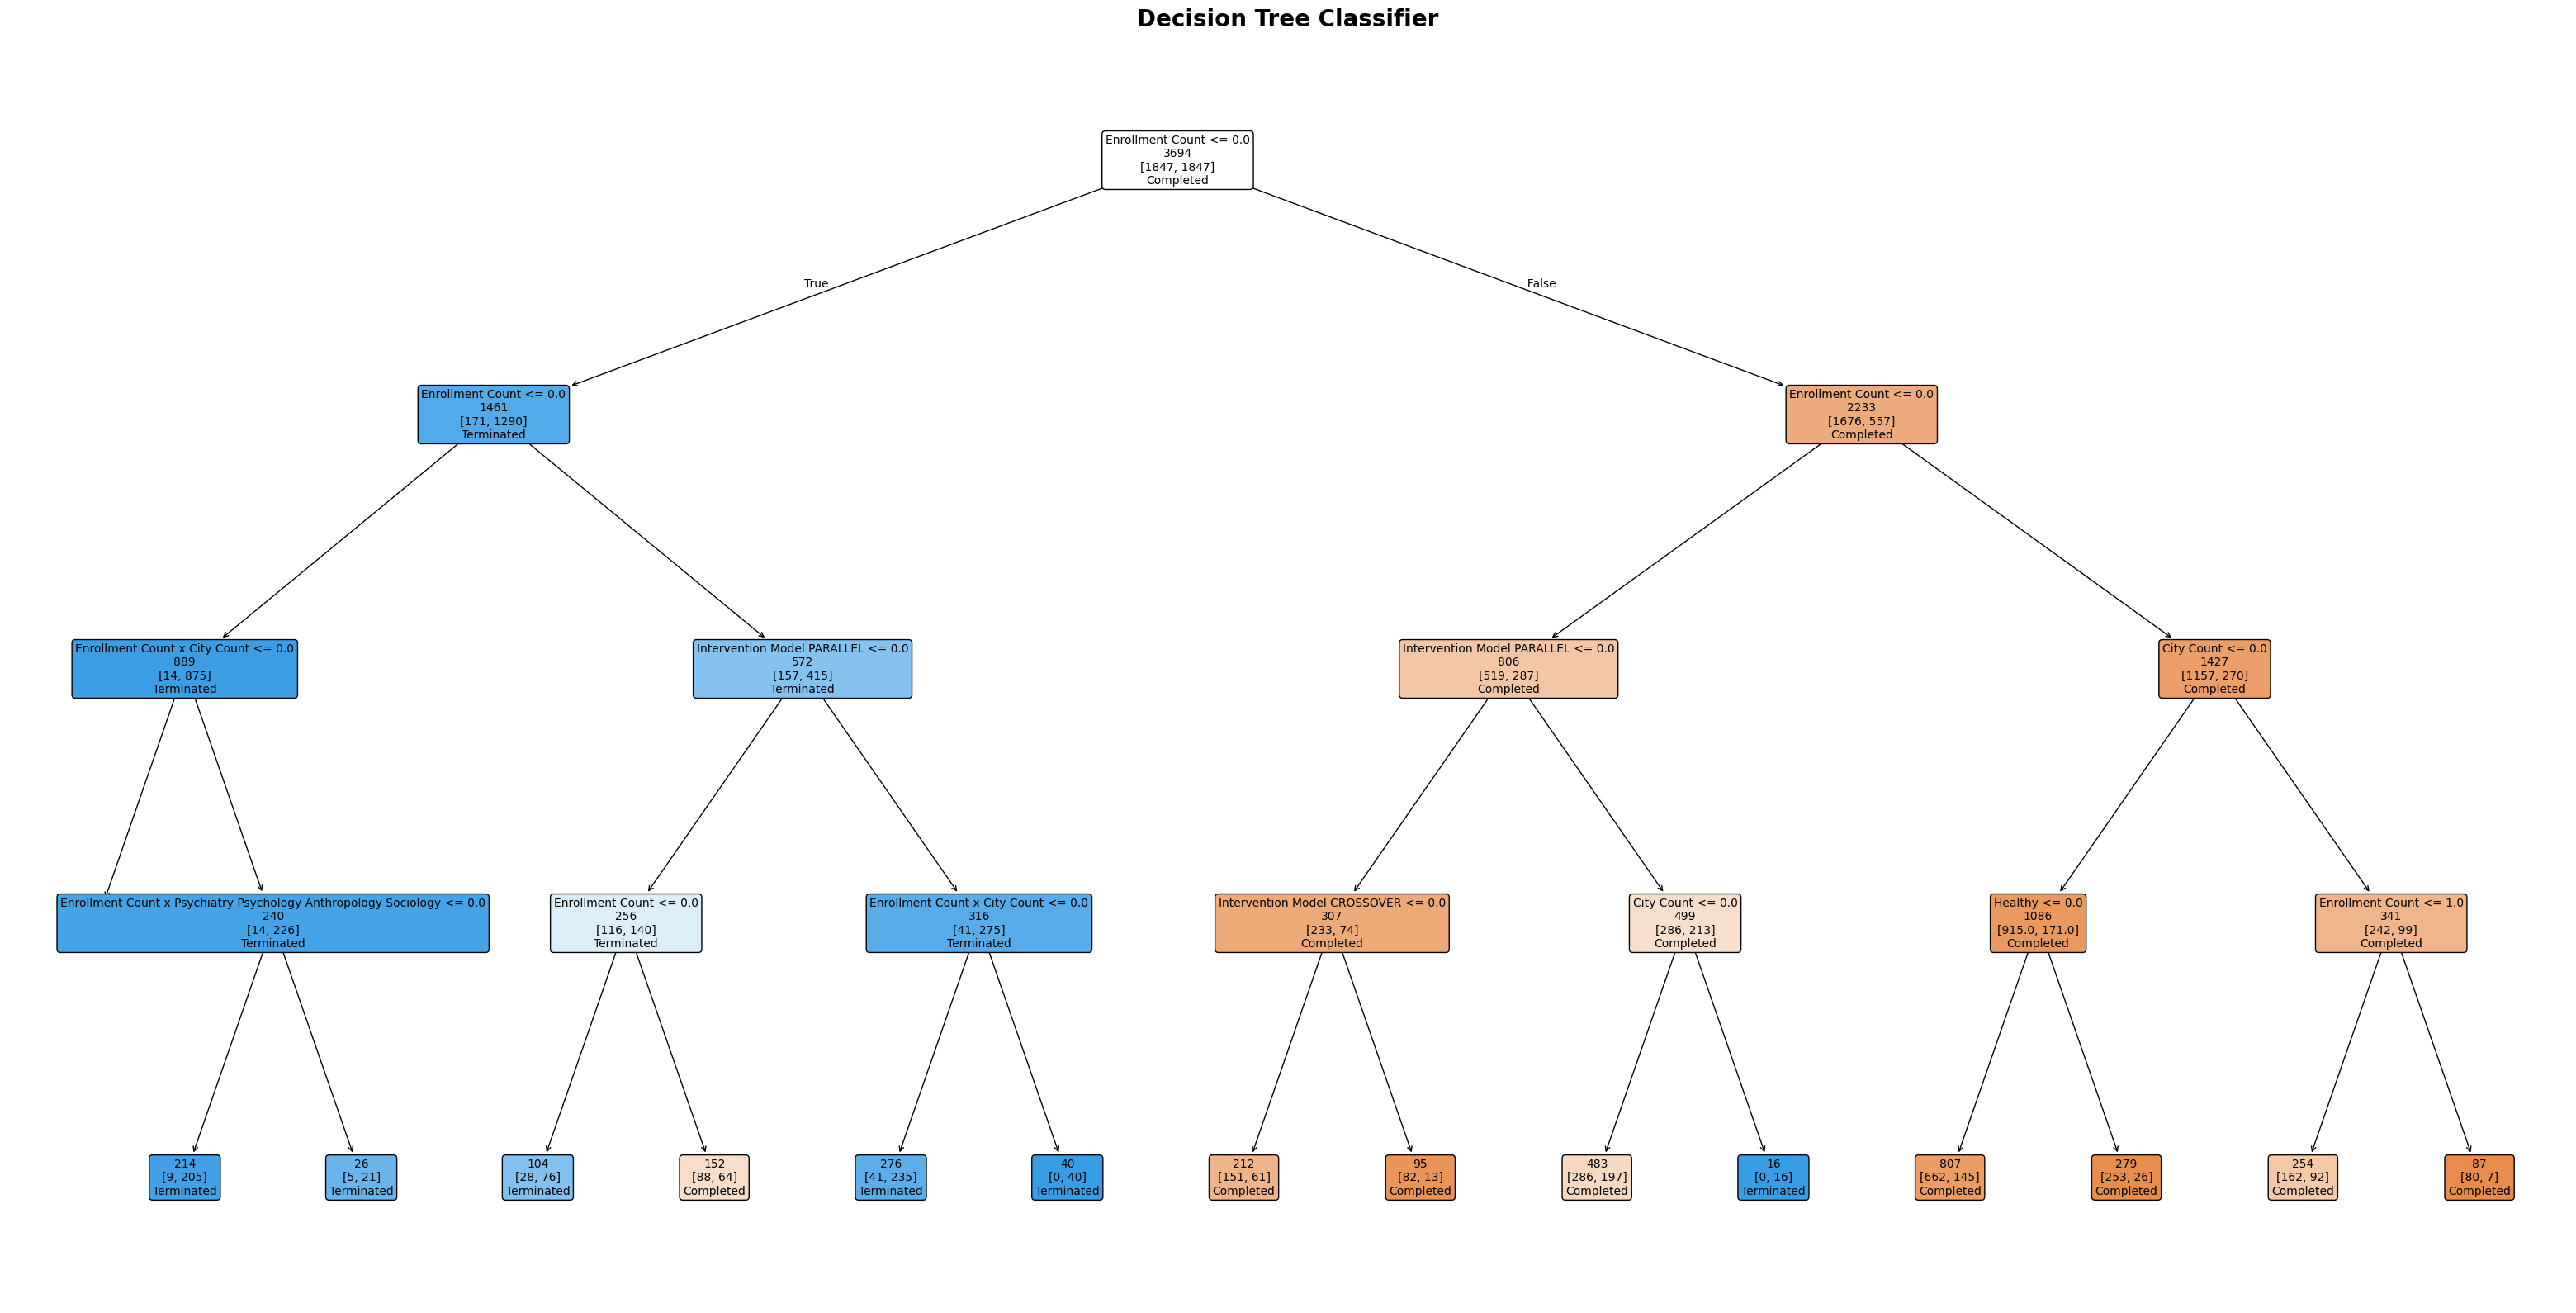

In [151]:
# Model 
tree = DecisionTreeClassifier(random_state = 42, class_weight = "balanced")

# Hyperparameters CV
param_grid = {
    'criterion': ['gini', 'entropy'],           # Splitting strategy
    'max_depth': [2, 3, 4, 5, 6, 7, None],      # give small depth as choice # Pre-pruning --> Built in feature Selection
    'min_samples_split': [2, 5, 10],            # Min samples to split a node
    'min_samples_leaf': [1, 2, 4],              # Min samples in a leaf
    'max_features': [None, 'sqrt', 'log2'],     # Max features to consider at each split
    'ccp_alpha': np.linspace(0, np.max(ccp_alphas), 10),   # Post-Pruning --> Cost-complexity parameter
}

# CV
grid = GridSearchCV(estimator = tree, param_grid = param_grid, cv = 5, n_jobs = -1)

# Final Model
tr_model = grid.fit(X_train, y_train)
display(f'Best Parameter criterion/max_depth: {tr_model.best_params_}')
display(f'Best Estimator : {tr_model.best_estimator_}')

# y_pred
y_pred_tr = tr_model.predict(X_test)

# Accuracy Score
ba_tr, class_tr, mcc_tr, f1_tr = accuracy(dfi, i, tr_model, X_test, y_test, y_pred_tr, "Decision Tree Classifier")

# Plot Tree
tree_clf = tr_model.best_estimator_

plt.figure(figsize = (40, 20))
plot_tree(
    tree_clf,
    feature_names = X_train.columns,
    class_names = ['Completed', 'Terminated'],
    max_depth = tr_model.best_params_['max_depth'],
    label = 'none',
    filled = True,
    rounded = True,
    proportion = False,
    impurity = False,
    precision = 0,
    fontsize = 10
)
plt.title("Decision Tree Classifier", fontsize = 20, fontweight = 'bold')
plt.show()

# SHAP
# tr_shap = fun_shap(i, tr_model, X_test, 'Tree')


### Random Forest

"Best Parameter criterion/bootstrap/n_estimators : {'bootstrap': True, 'criterion': 'entropy', 'max_features': 'sqrt'}"

"Best Estimator : RandomForestClassifier(class_weight='balanced', criterion='entropy',\n                       random_state=42)"

Model : Phase 4 - Random Forest Classifier

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      2188
           1       0.62      0.74      0.68       462

    accuracy                           0.88      2650
   macro avg       0.78      0.82      0.80      2650
weighted avg       0.89      0.88      0.88      2650


b).
F1 Score :
0.88

c).
Balanced Accuracy Score :
82.28%

d).
Matthews Correlation Coefficient (MCC) :
0.60

d).
Plots :
ROC AUC : 0.891
PR AUC : 0.788


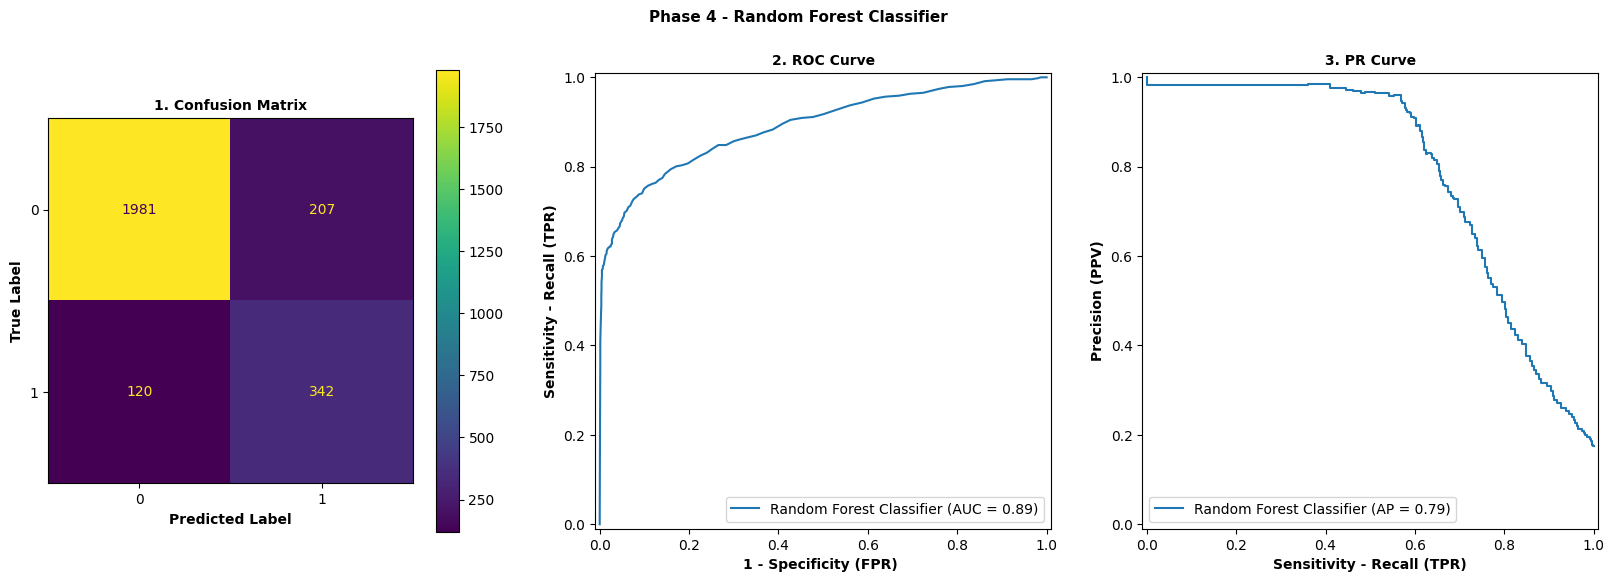

PermutationExplainer explainer: 101it [00:12,  1.77it/s]                         


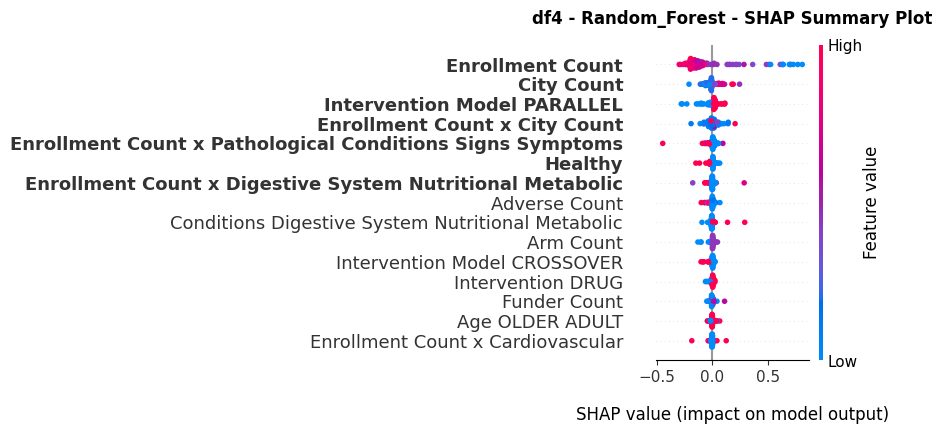

,Feature,df4_Random_Forest_Shap_Mean
0,Enrollment Count,0.216
1,City Count,0.040
2,Intervention Model PARALLEL,0.039
3,Enrollment Count x City Count,0.031
4,Enrollment Count x Pathological Conditions Sig...,0.022
5,Healthy,0.015
6,Enrollment Count x Digestive System Nutritiona...,0.013
7,Adverse Count,0.012


In [152]:
# Model 
forest = RandomForestClassifier(random_state = 42, class_weight = 'balanced')

# CV
param_grid = {
    "criterion" : ['gini', 'entropy', 'log_loss'], 
    "bootstrap" : [True, False],  # Bootstrap samples when building trees. If False, the whole dataset is used to build each tree.
    "max_features" : ["sqrt", "log2", None],  # None = m = p = Bagging Random Forest. / sqrt = m = sqrt(p) = Classic Random Forest. / log2 = m = log2(p) = Other Random Forest.
}

grid = GridSearchCV(estimator = forest , param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
rf_model = grid.fit(X_train, y_train)
display(f'Best Parameter criterion/bootstrap/n_estimators : {rf_model.best_params_}')
display(f'Best Estimator : {rf_model.best_estimator_}')

# y_pred
y_pred_rf = rf_model.predict(X_test)

# Accuracy Score
ba_rf, class_rf, mcc_rf, f1_rf = accuracy(dfi, i, rf_model, X_test, y_test, y_pred_rf, "Random Forest Classifier")

# SHAP
rf_shap = fun_shap(i, rf_model, X_test, 'Random_Forest')

### Gradient Boosting Classifier

"Best Parameter learning_rate : {'learning_rate': 0.05, 'max_depth': 3}"

'Best Estimator : GradientBoostingClassifier(learning_rate=0.05, random_state=42)'

Model : Phase 4 - Gradient Boosting Classifier

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      2188
           1       0.64      0.74      0.69       462

    accuracy                           0.88      2650
   macro avg       0.79      0.83      0.81      2650
weighted avg       0.89      0.88      0.89      2650


b).
F1 Score :
0.89

c).
Balanced Accuracy Score :
82.69%

d).
Matthews Correlation Coefficient (MCC) :
0.62

d).
Plots :
ROC AUC : 0.895
PR AUC : 0.801


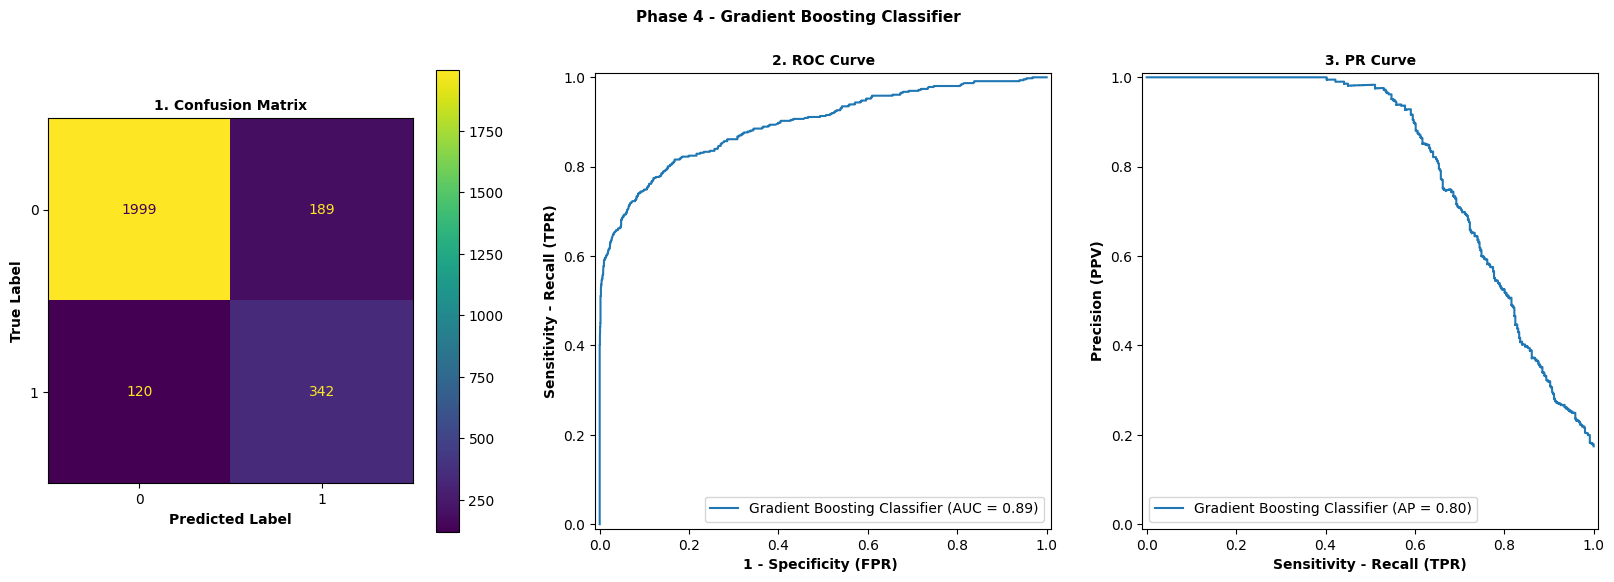

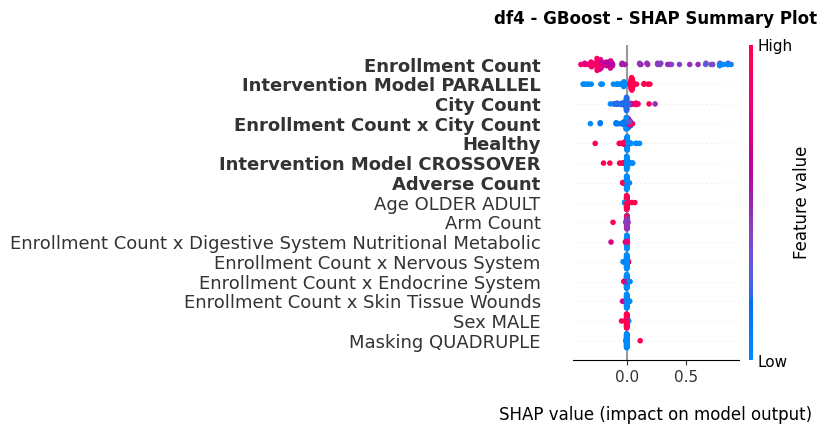

,Feature,df4_GBoost_Shap_Mean
0,Enrollment Count,0.304
1,Intervention Model PARALLEL,0.069
2,City Count,0.036
3,Enrollment Count x City Count,0.026
4,Healthy,0.016
5,Intervention Model CROSSOVER,0.011
6,Adverse Count,0.004
7,Age OLDER ADULT,0.004


In [153]:
# Model (+10 mins)
gra_boost = GradientBoostingClassifier(random_state = 42)  

# CV
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    }

grid = GridSearchCV(estimator = gra_boost , param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
gb_model = grid.fit(X_train, y_train)
display(f'Best Parameter learning_rate : {gb_model.best_params_}')
display(f'Best Estimator : {gb_model.best_estimator_}')

# y_pred
y_pred_gb = gb_model.predict(X_test)

# Accuracy Score
ba_gb, class_gb, mcc_gb, f1_gb = accuracy(dfi, i, gb_model, X_test, y_test, y_pred_gb, "Gradient Boosting Classifier")

# SHAP
gb_shap = fun_shap(i, gb_model, X_test, 'GBoost')

### Extreme Gradient Boost

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3}
Model : Phase 4 - XGBoosting Classifier

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2188
           1       0.60      0.76      0.67       462

    accuracy                           0.87      2650
   macro avg       0.77      0.83      0.79      2650
weighted avg       0.89      0.87      0.87      2650


b).
F1 Score :
0.87

c).
Balanced Accuracy Score :
82.57%

d).
Matthews Correlation Coefficient (MCC) :
0.59

d).
Plots :
ROC AUC : 0.895
PR AUC : 0.801


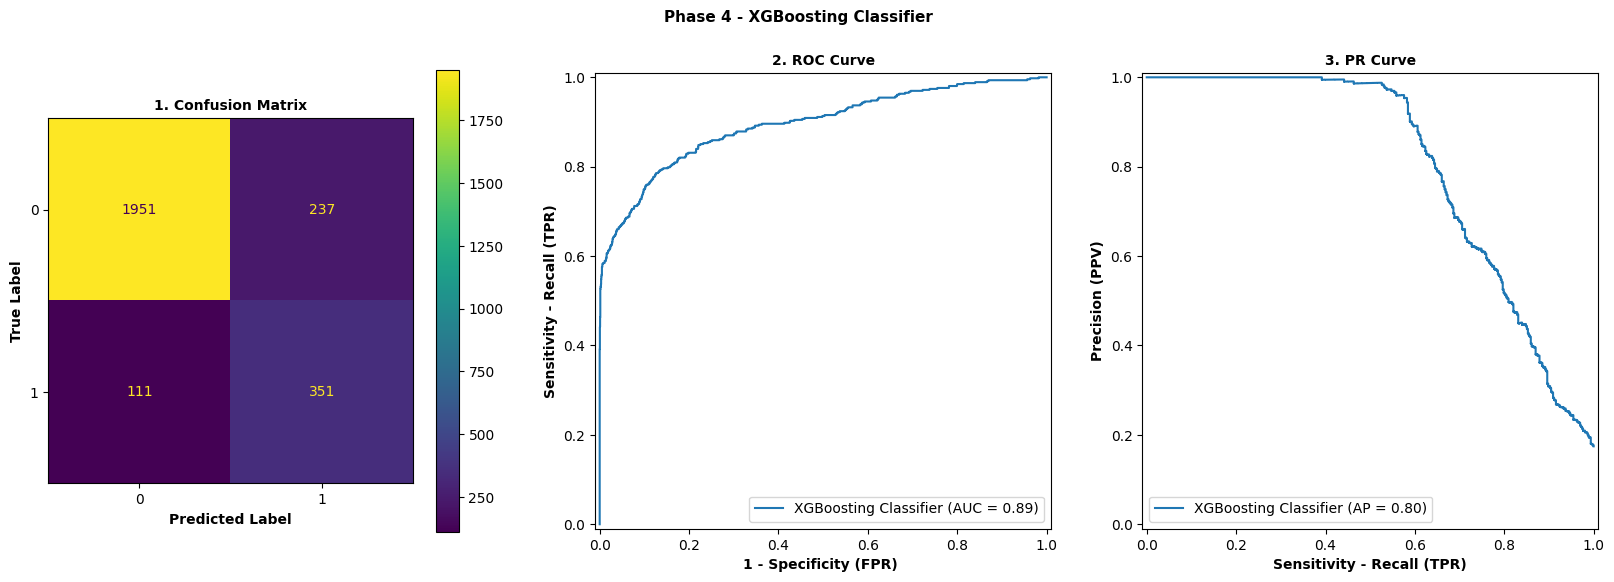

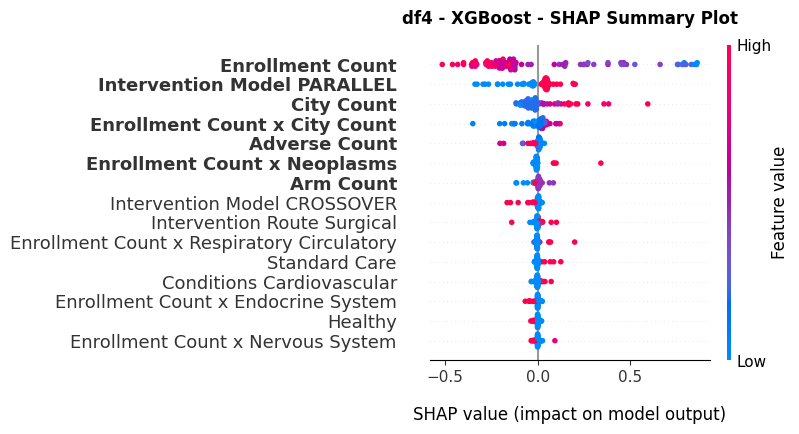

,Feature,df4_XGBoost_Shap_Mean
0,Enrollment Count,0.298
1,Intervention Model PARALLEL,0.070
2,City Count,0.068
3,Enrollment Count x City Count,0.038
4,Adverse Count,0.016
5,Enrollment Count x Neoplasms,0.013
6,Arm Count,0.012
7,Intervention Model CROSSOVER,0.011


In [154]:
# Model
xgb = XGBClassifier(objective = 'binary:logistic', eval_metric = 'logloss', random_state = 42) 
# Doc: For classification, ‘log_loss’.

# CV
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'colsample_bytree': [0.5, 0.7, 1.0]
    }

grid = GridSearchCV(estimator = xgb, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
xgb_model = grid.fit(X_train, y_train)
print("Best Parameters:", xgb_model.best_params_)
# print("Best Estimator:", xgb_model.best_estimator_) # too long output. 

# y_pred
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy Score
ba_xgb, class_xgb, mcc_xgb, f1_xgb = accuracy(dfi, i, xgb_model, X_test, y_test, y_pred_xgb, "XGBoosting Classifier")

# SHAP
xgb_shap = fun_shap(i, xgb_model, X_test, 'XGBoost')

### LightBoost

Best Parameters: {'feature_fraction': 0.7, 'learning_rate': 0.1, 'max_depth': 10, 'num_leaves': 10}
Model : Phase 4 - LightGBM Classifier

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2188
           1       0.60      0.74      0.67       462

    accuracy                           0.87      2650
   macro avg       0.77      0.82      0.79      2650
weighted avg       0.88      0.87      0.88      2650


b).
F1 Score :
0.88

c).
Balanced Accuracy Score :
82.04%

d).
Matthews Correlation Coefficient (MCC) :
0.59

d).
Plots :
ROC AUC : 0.897
PR AUC : 0.803


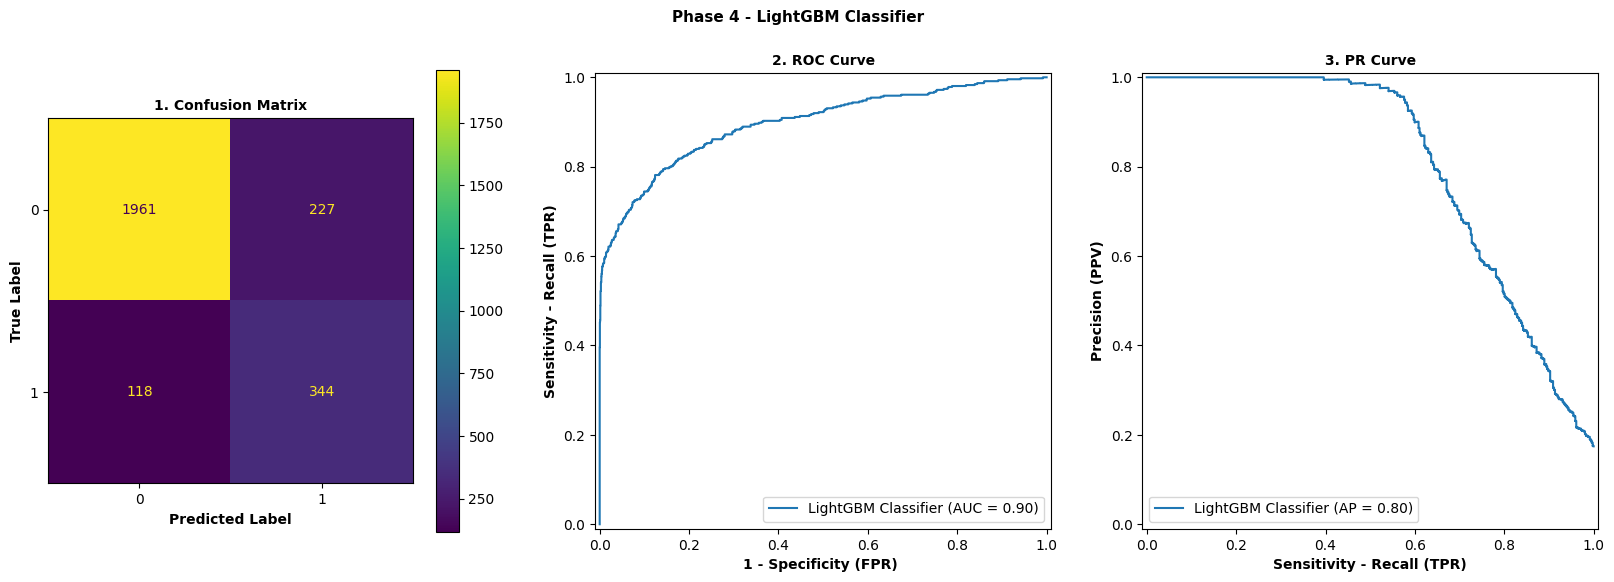

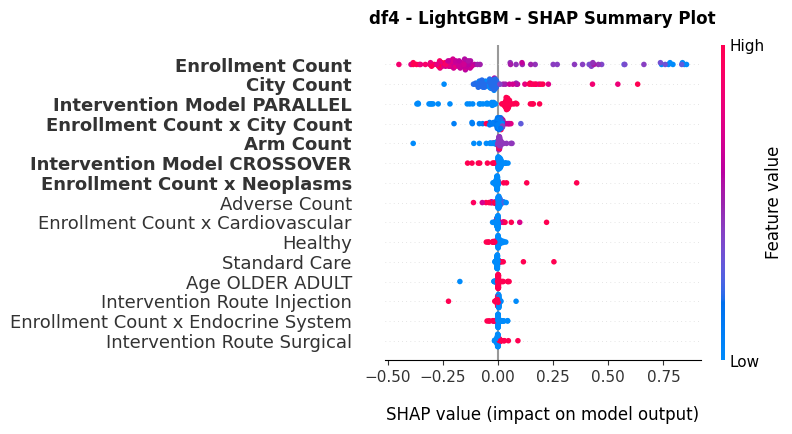

,Feature,df4_LightGBM_Shap_Mean
0,Enrollment Count,0.297
1,City Count,0.076
2,Intervention Model PARALLEL,0.073
3,Enrollment Count x City Count,0.020
4,Arm Count,0.016
5,Intervention Model CROSSOVER,0.012
6,Enrollment Count x Neoplasms,0.011
7,Adverse Count,0.010


In [155]:
# Model
lgb = LGBMClassifier(objective = 'binary', random_state = 42, n_jobs=-1, metric = 'binary_logloss', 
                     class_weight = 'balanced', verbose = -1) 
# Doc: For classification, ‘log_loss’.

# CV
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [10, 30, 50],
    'feature_fraction': [0.7, 1.0],
    'max_depth': [5, 10, 20]
}

grid = GridSearchCV(estimator = lgb, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
lgb_model = grid.fit(X_train, y_train)
print("Best Parameters:", lgb_model.best_params_)

# y_pred
y_pred_lgb = lgb_model.predict(X_test)

# Accuracy Score
ba_lgb, class_lgb, mcc_lgb, f1_lgb = accuracy(dfi, i, lgb_model, X_test, y_test, y_pred_lgb, "LightGBM Classifier")

# SHAP
lgb_shap = fun_shap(i, lgb_model, X_test, 'LightGBM')

# ROC Curve

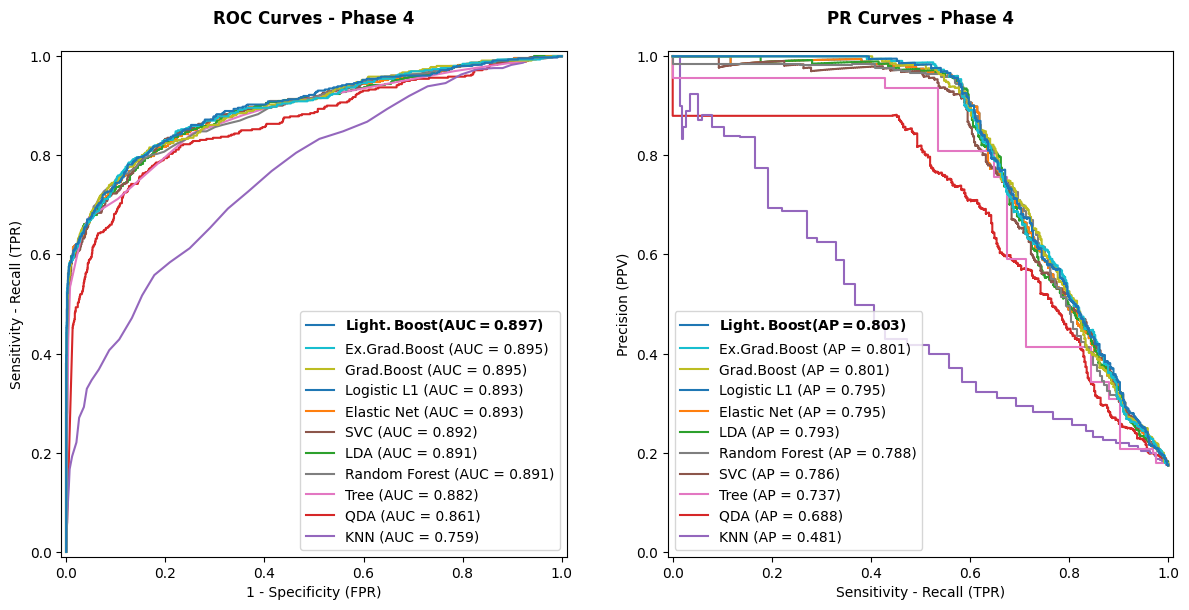

In [156]:
# Save Path
folder_roc = "roc_plots"
os.makedirs(folder_roc, exist_ok=True)
filename = f"roc_df{i}.png"
filepath = os.path.join(folder_roc, filename)

# Models
models = [
    ("Logistic L1", log_model, X_test, y_test),
    ("Elastic Net", el_model, X_test, y_test),
    ("LDA", lda_model, X_test, y_test),
    ("QDA", qda_model, X_test, y_test),
    ("KNN", knn_model, X_test, y_test),
    ("SVC", svc_model, X_test, y_test),
    ("Tree", tr_model, X_test, y_test),
    ("Random Forest", rf_model, X_test, y_test),
    ("Grad.Boost", gb_model, X_test, y_test),
    ("Ex.Grad.Boost", xgb_model, X_test, y_test),
    ("Light.Boost", lgb_model, X_test, y_test)
]

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 6))

roc_aucs = []
pr_aucs = []

for original_name, model, X_test_model, y_test_model in models:
    y_score = model.predict_proba(X_test_model)[:, 1]  

# ROC Curve
    auc = roc_auc_score(y_test_model, y_score)
    label_roc = f"{original_name} (AUC = {auc:.3f})"
    roc = RocCurveDisplay.from_estimator(
        model, X_test_model, y_test_model, ax=ax_roc,
        name=label_roc, pos_label = 1  # Completed = 0, Terminated = 1
    )
    roc_aucs.append((auc, label_roc, roc.line_))

# PR Curve
    ap = average_precision_score(y_test_model, y_score)
    label_pr = f"{original_name} (AP = {ap:.3f})"
    pr = PrecisionRecallDisplay.from_estimator(
        model, X_test_model, y_test_model, ax=ax_pr,
        name=label_pr, pos_label=1
    )
    pr_aucs.append((ap, label_pr, pr.line_))

# Sort models at legends
roc_aucs.sort(key=lambda x: x[0], reverse=True)
pr_aucs.sort(key=lambda x: x[0], reverse=True)

# Bold best model
roc_handles = [item[2] for item in roc_aucs]
roc_labels = [f"$\\bf{{{item[1]}}}$" if i == 0 else item[1] for i, item in enumerate(roc_aucs)]
ax_roc.legend(roc_handles, roc_labels, loc = "lower right")

pr_handles = [item[2] for item in pr_aucs]
pr_labels = [f"$\\bf{{{item[1]}}}$" if i == 0 else item[1] for i, item in enumerate(pr_aucs)]
ax_pr.legend(pr_handles, pr_labels, loc = "lower left")

# Titles/ labels
ax_roc.set_title(f"ROC Curves - Phase {i}", fontsize = 12, fontweight = 'bold', pad = 20)
ax_roc.set_xlabel("1 - Specificity (FPR)", fontsize = 10)
ax_roc.set_ylabel("Sensitivity - Recall (TPR)", fontsize = 10)

ax_pr.set_title(f"PR Curves - Phase {i}", fontsize = 12, fontweight = 'bold', pad = 20)
ax_pr.set_ylabel("Precision (PPV)", fontsize = 10)
ax_pr.set_xlabel("Sensitivity - Recall (TPR)", fontsize = 10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2) 

# Save Plot
plt.savefig(filepath, dpi=100, bbox_inches="tight")
plt.show()
plt.close()

# Metrics
= MCC [-1, 1]
- MCC = 0 = Random Guessing 

In [157]:
MCC = pd.DataFrame({
        'Models': ['Logistic', 'Elastic Net', 'LDA', 'QDA', 'KNN', 'SVC', 'Tree', 'Random_Forest', 'Grad_Boost', 
                   'Ex_Grad_Boost', 'LightGBM'],\
        'MCC': [mcc_log, mcc_el, mcc_lda, mcc_qda, mcc_knn, mcc_svc, mcc_tr, mcc_rf, mcc_gb, mcc_xgb, mcc_lgb]  # mcc_el, mcc_tr
                }).sort_values(by = 'MCC', ascending = False)

ACC = pd.DataFrame({
        'Models': ['Logistic', 'Elastic Net', 'LDA', 'QDA', 'KNN', 'SVC', 'Tree', 'Random_Forest', 'Grad_Boost', 
                   'Ex_Grad_Boost', 'LightGBM'],\
        'ACC': [ba_log, ba_el, ba_lda, ba_qda, ba_knn, ba_svc, ba_tr, ba_rf, ba_gb, ba_xgb, ba_lgb]  # ba_el, ba_tr
                }).sort_values(by = 'ACC', ascending = False)

F1 = pd.DataFrame({
        'Models': ['Logistic', 'Elastic Net', 'LDA', 'QDA', 'KNN', 'SVC', 'Tree', 'Random_Forest', 'Grad_Boost', 
                   'Ex_Grad_Boost', 'LightGBM'],\
        'F1': [f1_log, f1_el, f1_lda, f1_qda, f1_knn, f1_svc, f1_tr, f1_rf, f1_gb, f1_xgb, f1_lgb]  # f1_el, f1_tr
                }).sort_values(by = 'F1', ascending = False)

metrics = pd.merge(MCC, F1, on = 'Models')
metrics = pd.merge(metrics, ACC, on = 'Models')
metrics = metrics.sort_values(by = ['MCC', 'ACC', 'F1'], ascending = False)
metrics.index.name = f'df{i}'
metrics

,Models,MCC,F1,ACC
df4,,,,
0,Tree,0.66,0.90,81.46%
1,Grad_Boost,0.62,0.89,82.69%
3,Random_Forest,0.60,0.88,82.28%
2,SVC,0.60,0.88,81.49%
4,Ex_Grad_Boost,0.59,0.87,82.57%
5,LightGBM,0.59,0.88,82.04%
6,LDA,0.56,0.86,81.21%
7,Logistic,0.55,0.85,81.95%
8,Elastic Net,0.55,0.85,81.95%


# Logistic Interpretention

In [158]:
X = X_test[xgb_shap['Feature'].to_list()]
display(xgb_shap)

X = sm.add_constant(X)
y = y_test

model = sm.Logit(y, X)
results = model.fit(method = 'lbfgs', maxiter = 1000)
print(results.summary())
print("\n")

,Feature,df4_XGBoost_Shap_Mean
0,Enrollment Count,0.298
1,Intervention Model PARALLEL,0.070
2,City Count,0.068
3,Enrollment Count x City Count,0.038
4,Adverse Count,0.016
5,Enrollment Count x Neoplasms,0.013
6,Arm Count,0.012
7,Intervention Model CROSSOVER,0.011


                           Logit Regression Results                           
Dep. Variable:           Study Status   No. Observations:                 2650
Model:                          Logit   Df Residuals:                     2641
Method:                           MLE   Df Model:                            8
Date:                Tue, 28 Oct 2025   Pseudo R-squ.:                  0.4649
Time:                        04:10:12   Log-Likelihood:                -656.07
converged:                       True   LL-Null:                       -1226.2
Covariance Type:            nonrobust   LLR p-value:                8.037e-241
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             2.1289      0.350      6.089      0.000       1.444       2.814
Enrollment Count                -18.9143      1.139    -16.601      0.000 

# Save Metrics

In [159]:
metrics.to_pickle(f"./shap_plots/df{i}_metrics.pkl")

# Time

In [160]:
end_time = time.time()
elapsed_minutes = (end_time - start_time) / 60
print(f"df{i} - Execution time: {elapsed_minutes:.0f} minutes")

df4 - Execution time: 6 minutes
